In [22]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (r2_score, mean_squared_error, mean_absolute_error)


In [23]:

df = pd.read_csv('lego.sample.csv', encoding='cp1252')
df.head()

,Item_Number,Set_Name,Theme,Pieces,Price,Amazon_Price,Year,Ages,Pages,Minifigures,Packaging,Weight,Unique_Pieces,Availability,Size
0,10859,My First Ladybird,DUPLO®,6,$4.99,$16.00,2018,Ages_1½-3,9,NaN,Box,NaN,5,Retail,Large
1,10860,My First Race Car,DUPLO®,6,$4.99,$9.45,2018,Ages_1½-3,9,NaN,Box,0.13Kg (0.29 lb),6,Retail,Large
2,10862,My First Celebration,DUPLO®,41,$14.99,$39.89,2018,Ages_1½-3,9,NaN,Box,NaN,18,NaN,Large
3,10864,Large Playground Brick Box,DUPLO®,71,$49.99,$56.69,2018,Ages_2-5,32,2.0,Plastic box,1.41Kg (3.11 lb),49,NaN,Large
4,10867,Farmers' Market,DUPLO®,26,$19.99,$36.99,2018,Ages_2-5,9,3.0,Box,NaN,18,NaN,Large


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Item_Number    75 non-null     int64  
 1   Set_Name       75 non-null     str    
 2   Theme          75 non-null     str    
 3   Pieces         75 non-null     int64  
 4   Price          75 non-null     str    
 5   Amazon_Price   75 non-null     str    
 6   Year           75 non-null     int64  
 7   Ages           75 non-null     str    
 8   Pages          75 non-null     int64  
 9   Minifigures    65 non-null     float64
 10  Packaging      68 non-null     str    
 11  Weight         39 non-null     str    
 12  Unique_Pieces  75 non-null     int64  
 13  Availability   62 non-null     str    
 14  Size           75 non-null     str    
dtypes: float64(1), int64(5), str(9)
memory usage: 8.9 KB


**This is for data_cleaning**

In [25]:
df['Price'] = (
    df['Price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

print(df['Price'].dtype)
print(df['Price'].head())


df['Amazon_Price'] = (
    df['Amazon_Price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)

df['Amazon_Price'] = pd.to_numeric(df['Amazon_Price'], errors='coerce')

print(df['Amazon_Price'].dtype)
print(df['Amazon_Price'].head())


X = df[["Price","Theme", "Pieces", "Size"]]
y = df['Amazon_Price']


float64
0     4.99
1     4.99
2    14.99
3    49.99
4    19.99
Name: Price, dtype: float64
float64
0    16.00
1     9.45
2    39.89
3    56.69
4    36.99
Name: Amazon_Price, dtype: float64


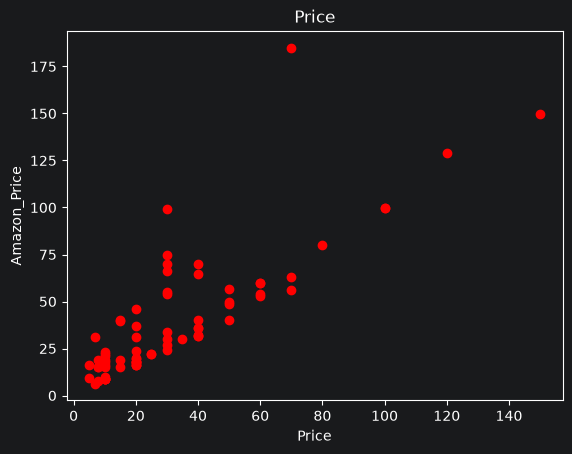

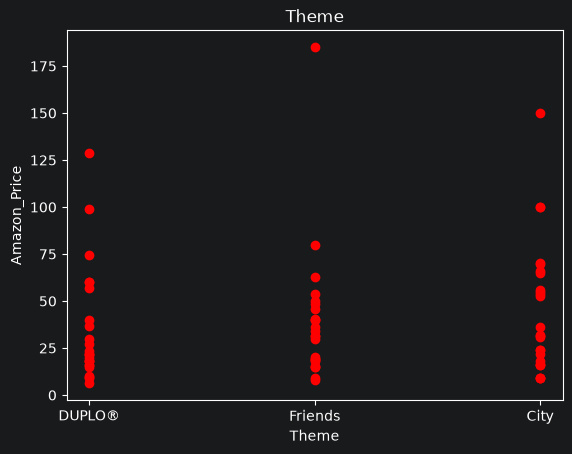

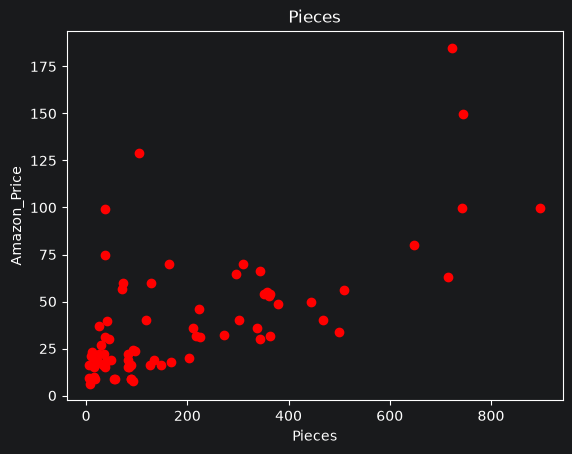

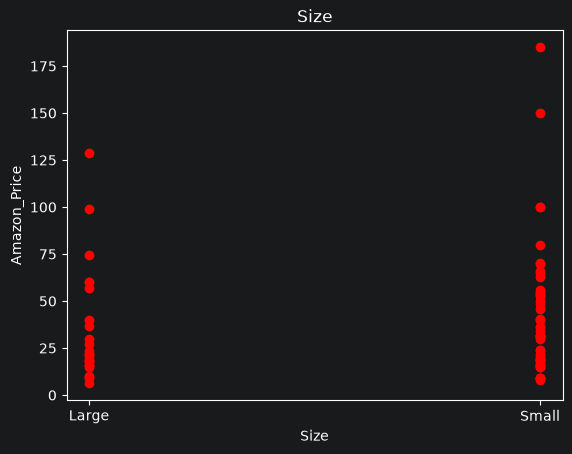

In [26]:
a = ["Price","Theme", "Pieces", "Size"]

for i in a:
    plt.scatter(df[i], df['Amazon_Price'], color= 'red')
    plt.title(i)
    plt.xlabel(i)
    plt.ylabel('Amazon_Price')
    plt.show()


this is for merge the x and y into one dataset

In [27]:
data = pd.concat([X, y], axis=1).dropna()
data.head()

,Price,Theme,Pieces,Size,Amazon_Price
0,4.99,DUPLO®,6,Large,16.00
1,4.99,DUPLO®,6,Large,9.45
2,14.99,DUPLO®,41,Large,39.89
3,49.99,DUPLO®,71,Large,56.69
4,19.99,DUPLO®,26,Large,36.99


In [28]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Price         75 non-null     float64
 1   Theme         75 non-null     str    
 2   Pieces        75 non-null     int64  
 3   Size          75 non-null     str    
 4   Amazon_Price  75 non-null     float64
dtypes: float64(2), int64(1), str(2)
memory usage: 3.1 KB


**This is for encoding like make string into number like 0, 1, 2**

In [29]:
X = data[['Price', 'Pieces', 'Theme', 'Size']]
y = data['Amazon_Price']

X = pd.get_dummies(
    X,
    columns=['Theme', 'Size'],
    dtype=int
)

In [30]:
print(X.head(15))

     Price  Pieces  Theme_City  Theme_DUPLO®  Theme_Friends  Size_Large  \
0     4.99       6           0             1              0           1   
1     4.99       6           0             1              0           1   
2    14.99      41           0             1              0           1   
3    49.99      71           0             1              0           1   
4    19.99      26           0             1              0           1   
5     9.99      16           0             1              0           1   
6    24.99      26           0             1              0           1   
7   119.99     105           0             1              0           1   
8    29.99      38           0             1              0           1   
9    29.99      37           0             1              0           1   
10   19.99      23           0             1              0           1   
11   19.99      15           0             1              0           1   
12   19.99      34       

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Interceptor:", model.intercept_)
print("Coefficient:", model.coef_)
print()

for feature, coef in zip(X_train.columns, model.coef_):
    print(f"{feature:20} : {coef:.4f}")
print()

y_pred = model.predict(X_test)
print(y_pred)
print()
print("R2 Value :", r2_score(y_test, y_pred))
print("Mean Absolute Error :", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error :", mean_squared_error(y_test, y_pred))



Interceptor: 8.17067201915303
Coefficient: [ 0.90494282  0.00213933  0.84220176 -0.19745299 -0.64474877 -0.19745299
  0.19745299]

Price                : 0.9049
Pieces               : 0.0021
Theme_City           : 0.8422
Theme_DUPLO®         : -0.1975
Theme_Friends        : -0.6447
Size_Large           : -0.1975
Size_Small           : 0.1975

[25.92119554 37.11544064 25.91477757 12.30426668 53.96267239 18.43896624
 72.60491758 25.93831015 18.44110557 45.98302619 72.5899423  16.868582
 53.91132858 30.46730292 34.99415636]

R2 Value : 0.38526565008005687
Mean Absolute Error : 19.843258206263325
Mean Squared Error : 1205.979991030489


In [32]:
data.head()

,Price,Theme,Pieces,Size,Amazon_Price
0,4.99,DUPLO®,6,Large,16.00
1,4.99,DUPLO®,6,Large,9.45
2,14.99,DUPLO®,41,Large,39.89
3,49.99,DUPLO®,71,Large,56.69
4,19.99,DUPLO®,26,Large,36.99


In [33]:
print(X.head())

   Price  Pieces  Theme_City  Theme_DUPLO®  Theme_Friends  Size_Large  \
0   4.99       6           0             1              0           1   
1   4.99       6           0             1              0           1   
2  14.99      41           0             1              0           1   
3  49.99      71           0             1              0           1   
4  19.99      26           0             1              0           1   

   Size_Small  
0           0  
1           0  
2           0  
3           0  
4           0  


In [34]:
print(model.predict([[19.99, 6, 1, 0, 0, 1, 0]]))

[26.91806379]


F:\ML algorithm\.venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [36]:
print(model.predict([[25.99, 41, 0, 0, 1, 1, 0]]))

[30.93564659]


F:\ML algorithm\.venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
